In [ ]:
import IPython; IPython.display.display(IPython.display.Javascript('setInterval(()=>document.querySelector("colab-toolbar-button#connect")?.click(), 60000)'))

In [ ]:
# -----------------------------------------------------------------------------
# Bootstrap (added by patch v2): Colab + Google Drive aware
# -----------------------------------------------------------------------------
import os, sys, subprocess, pathlib

IN_COLAB = "google.colab" in sys.modules
if not IN_COLAB:
    try:
        import google.colab  # noqa: F401
        IN_COLAB = True
    except Exception:
        IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    if not os.path.ismount("/content/drive"):
        drive.mount("/content/drive")
    PROJECT_ROOT = pathlib.Path("/content/drive/MyDrive/EarningsLens")
    # The unpacked codebase (movingtargetLM/src/) should sit alongside the
    # notebooks under MyDrive/EarningsLens/. Adjust if your layout differs.
    CODEBASE_ROOT = PROJECT_ROOT
else:
    # Local fallback: assume the workspace layout produced by patch_v2.
    PROJECT_ROOT  = pathlib.Path(os.environ.get(
        "EARNINGSLENS_ROOT",
        "/home/user/workspace/earningslens_real",
    ))
    CODEBASE_ROOT = PROJECT_ROOT

DATA_DIR      = PROJECT_ROOT / "data"
RAW_DIR       = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUTS_DIR   = PROJECT_ROOT / "outputs"
for d in (RAW_DIR, PROCESSED_DIR, OUTPUTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

sys.path.append('/content/drive/MyDrive/EarningsLens/src')

# Make `from src.<...> import ...` work
if str(CODEBASE_ROOT) not in sys.path:
    sys.path.insert(0, str(CODEBASE_ROOT))

# Install the runtime deps actually used by NB02..NB08 (idempotent).
_REQUIRED = [
    "polars", "duckdb", "pyarrow", "pandas", "numpy", "matplotlib",
    "seaborn", "scikit-learn", "scipy", "rapidfuzz", "spacy",
    "google-genai", "tiktoken", "httpx", "rank-bm25", "sentence-transformers",
    "chromadb", "tenacity", "tqdm",
]
def _ensure_packages():
    missing = []
    for pkg in _REQUIRED:
        mod = pkg.replace("-", "_")
        try:
            __import__(mod)
        except Exception:
            missing.append(pkg)
    if missing:
        print(f"Installing: {missing}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
_ensure_packages()

# spaCy model (en_core_web_lg) - used by NB02 and NB04
try:
    import spacy
    spacy.load("en_core_web_sm")
except Exception:
    print("Downloading spaCy en_core_web_lg ...")
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_lg"])

print(f"Bootstrap OK | IN_COLAB={IN_COLAB}")
print(f"  PROJECT_ROOT  = {PROJECT_ROOT}")
print(f"  CODEBASE_ROOT = {CODEBASE_ROOT}")
print(f"  RAW_DIR       = {RAW_DIR}")
print(f"  PROCESSED_DIR = {PROCESSED_DIR}")

Installing: ['scikit-learn', 'google-genai', 'chromadb']
Bootstrap OK | IN_COLAB=True
  PROJECT_ROOT  = /content/drive/MyDrive/EarningsLens
  CODEBASE_ROOT = /content/drive/MyDrive/EarningsLens
  RAW_DIR       = /content/drive/MyDrive/EarningsLens/data/raw
  PROCESSED_DIR = /content/drive/MyDrive/EarningsLens/data/processed


# 03 — LLM-Powered Semantic Target Extraction

## Overview

This notebook walks through every stage of the LLM-based extraction pipeline for EarningsLens:
the prompt design, single-call experiments, comparison with spaCy, prompt-variant ablations,
batch processing via the `LLMTargetExtractor` class, long-transcript handling, error handling,
cost estimation, and a full-corpus run.

---

## Why LLMs Instead of spaCy NER?

The spaCy baseline in `src/baseline/target_extractor.py` uses NER entity labels
(`MONEY`, `PERCENT`, `PRODUCT`, `CARDINAL`, `QUANTITY`) combined with dependency-parsed
"goal verb" triggers (`achieve`, `target`, `maintain`, …) to identify performance targets.
This replicates the Cohen & Nguyen (2024) methodology and works well for clean, numerical targets.

However, it has three systematic blind spots that degrade the **Moving Targets (MT)** signal:

1. **Syntactic fragility** — the three-criterion rule (NER + nummod + goal-verb) must fire
   simultaneously in the same dependency subtree. Any syntactic variation breaks it. A sentence
   like *"double-digit cloud growth, consistent with prior quarters"* contains no `MONEY` or
   `PERCENT` entity, so spaCy emits nothing.

2. **False-positive drops from rephrasing** — when management says *"comparable-store sales
   momentum"* in Q2 instead of *"same-store sales growth"* in Q1, exact-string matching flags
   the Q1 target as *dropped* even though the KPI is unchanged. This injects noise into the MT
   measure, biasing return-predictability tests.

3. **No contextual reasoning** — spaCy cannot interpret implicit commitments (*"we see no reason
   that trajectory changes"*) or recognize that 2 billion active devices is a tracked operational
   target even though it is a `CARDINAL`, not a `MONEY`, entity.

GPT-4o-mini with a chain-of-thought extraction prompt addresses all three: it reasons about
management intent, normalizes synonymous phrasings into canonical metric names, and flags
trend-based commitments without explicit numeric anchors.

In [ ]:
import os
from google.colab import userdata

# Load GEMINI_API_KEY from Colab Secrets.
# NEVER paste a literal key into this notebook.
try:
    GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
    os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY
except userdata.SecretNotFoundError:
    raise RuntimeError(
        "GEMINI_API_KEY missing. Add it to the Colab Secrets manager (key icon on the left panel)."
    )

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Setup: imports, environment variables, and path configuration
# ─────────────────────────────────────────────────────────────────────────────
import asyncio
import importlib
import json
import logging
import os
import re
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import seaborn as sns
from tqdm.auto import tqdm

# ── Logging (silence noisy transport loggers) ─────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(name)s  %(message)s",
    datefmt="%H:%M:%S",
)
for _noisy in ("httpx", "httpcore", "urllib3"):
    logging.getLogger(_noisy).setLevel(logging.WARNING)
logger = logging.getLogger("nb03")

# ── Gemini API key (loaded by Cell 1) ────────────────────────────────────────
GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY", "")
if not GEMINI_API_KEY:
    raise RuntimeError(
        "GEMINI_API_KEY missing. Set it in the Colab secrets before running."
    )

# ── Data paths (Reuse from Bootstrap Cell) ────────────────────────
REPO_ROOT = PROJECT_ROOT
DATA_ROOT = DATA_DIR
DATA_RAW = RAW_DIR
DATA_PROCESSED = PROCESSED_DIR
DATA_CACHE = DATA_ROOT / "cache"
DATA_CACHE.mkdir(parents=True, exist_ok=True)

print(f"REPO_ROOT      : {REPO_ROOT}")
print(f"DATA_ROOT      : {DATA_ROOT}")
print(f"DATA_PROCESSED : {DATA_PROCESSED}")
print(f"Gemini API key : loaded ({len(GEMINI_API_KEY)} chars)")

REPO_ROOT      : /content/drive/MyDrive/EarningsLens
DATA_ROOT      : /content/drive/MyDrive/EarningsLens/data
DATA_PROCESSED : /content/drive/MyDrive/EarningsLens/data/processed
Gemini API key : loaded (39 chars)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Load transcript components.
#
# Sampling strategy (fixed to enable Moving Targets computation):
#
# The Moving Targets measure MT_{i,t} = |T_{i,t-4} \ T_{i,t}| / |T_{i,t-4}|
# requires year-over-year target sets per firm. The previous version of this
# cell sampled the first 200 transcript IDs from row-group-0 of the parquet,
# which only covered 2010 Q1 — making MT undefined.
#
# Fix: align the LLM panel with the spaCy baseline panel that 02_spacy_baseline
# already produced. We read the (companyid, fiscalyear, fiscalquarter) keys
# spaCy covers, then load exactly those transcripts from the CIQ parquet.
# This guarantees apples-to-apples comparability in Section 10.
#
# If the spaCy parquet is missing, we fall back to a stratified random sample
# of N firms × all available quarters — still multi-year, never single-quarter.
# ─────────────────────────────────────────────────────────────────────────────
SAMPLE_FIRMS_FALLBACK = 30   # used only if spaCy panel is missing
SEED = 42

ciq_path_candidates = [
    DATA_RAW / "ciq_transcripts.parquet",
    REPO_ROOT / "data" / "ciq_transcripts.parquet",
    REPO_ROOT / "data" / "raw" / "ciq_transcripts.parquet",
]
ciq_path = next((p for p in ciq_path_candidates if p.exists()), None)
if ciq_path is None:
    raise FileNotFoundError("ciq_transcripts.parquet not found in DATA_RAW or DATA_ROOT.")

spacy_targets_path = DATA_PROCESSED / "spacy_targets.parquet"

USE_COLS = [
    "companyid", "transcriptid", "component_type_id", "componenttext",
    "event_date", "transcriptcomponentid", "componentorder",
]
COMPONENT_TYPES = [2, 3, 4]   # Presentation, Question, Answer (per CIQ schema)

if spacy_targets_path.exists():
    sp = pd.read_parquet(
        spacy_targets_path, columns=["companyid", "fiscalyear", "fiscalquarter"]
    )
    panel_keys = (
        sp.dropna(subset=["companyid", "fiscalyear", "fiscalquarter"])
          .astype({"companyid": "Int64", "fiscalyear": "Int64", "fiscalquarter": "Int64"})
          .drop_duplicates()
    )
    target_company_ids = panel_keys["companyid"].astype(float).unique().tolist()
    sampling_strategy = (
        f"spaCy panel ({len(panel_keys):,} firm-quarters, "
        f"{panel_keys['companyid'].nunique()} firms, "
        f"{panel_keys['fiscalyear'].min()}-{panel_keys['fiscalyear'].max()})"
    )
else:
    pf = pq.ParquetFile(ciq_path)
    company_ids_seen: set[float] = set()
    for rg_idx in range(min(pf.num_row_groups, 8)):
        chunk = pf.read_row_group(rg_idx, columns=["companyid"]).to_pandas()
        company_ids_seen.update(chunk["companyid"].dropna().unique().tolist())
    rng = np.random.default_rng(SEED)
    sampled = rng.choice(
        sorted(company_ids_seen), size=min(SAMPLE_FIRMS_FALLBACK, len(company_ids_seen)),
        replace=False,
    )
    target_company_ids = sampled.tolist()
    panel_keys = None
    sampling_strategy = f"fallback random {len(target_company_ids)} firms"

print(f"Sampling strategy : {sampling_strategy}")
print(f"Companies to load : {len(target_company_ids):,}")
print(f"Loading from      : {ciq_path}")

raw_df = pd.read_parquet(
    ciq_path,
    columns=USE_COLS,
    filters=[
        ("component_type_id", "in", COMPONENT_TYPES),
        ("companyid", "in", target_company_ids),
    ],
).rename(columns={"component_type_id": "component_type", "componenttext": "text", "event_date": "call_date"})

raw_df["call_date"] = pd.to_datetime(raw_df["call_date"], errors="coerce")
raw_df = raw_df.dropna(subset=["call_date", "text"]).copy()
raw_df["fiscalyear"] = raw_df["call_date"].dt.year.astype(int)
raw_df["fiscalquarter"] = raw_df["call_date"].dt.quarter.astype(int)

# If we have an explicit panel from spaCy, restrict exactly to those firm-quarters.
if panel_keys is not None:
    panel_keys = panel_keys.astype({"companyid": "float64",
                                     "fiscalyear": "int64",
                                     "fiscalquarter": "int64"})
    raw_df = raw_df.merge(panel_keys, on=["companyid", "fiscalyear", "fiscalquarter"],
                          how="inner")

raw_df = raw_df.sort_values(
    ["companyid", "fiscalyear", "fiscalquarter", "componentorder"]
).reset_index(drop=True)

transcripts_df = raw_df

required_cols = ["companyid", "fiscalyear", "fiscalquarter", "component_type", "text"]
missing = [c for c in required_cols if c not in transcripts_df.columns]
if missing:
    raise ValueError(f"Input dataframe missing required columns: {missing}")

n_firms = transcripts_df["companyid"].nunique()
nn_keys = transcripts_df.groupby(["companyid", "fiscalyear", "fiscalquarter"]).ngroups
yr_min = int(transcripts_df["fiscalyear"].min())
yr_max = int(transcripts_df["fiscalyear"].max())

print(f"Loaded {len(transcripts_df):,} component rows")
print(f"  firms                : {n_firms}")
print(f"  firm-quarters        : {nn_keys}")
print(f"  year range           : {yr_min}-{yr_max}")
print(f"  component-type counts: {transcripts_df['component_type'].value_counts().to_dict()}")
print()
transcripts_df.head()


Sampling strategy : spaCy panel (10,395 firm-quarters, 197 firms, 2010-2023)
Companies to load : 197
Loading from      : /content/drive/MyDrive/EarningsLens/data/raw/ciq_transcripts.parquet
Loaded 624,194 component rows
  firms                : 197
  firm-quarters        : 10395
  year range           : 2010-2023
  component-type counts: {np.int64(4): 343069, np.int64(3): 240904, np.int64(2): 40221}



,companyid,transcriptid,component_type,text,call_date,transcriptcomponentid,componentorder,fiscalyear,fiscalquarter
0,18711.0,49605,2,"Thanks, Matt, and good morning everyone and th...",2010-02-11,3782132,2,2010,1
1,18711.0,49605,2,"Well, good morning and thanks for your continu...",2010-02-11,3782133,3,2010,1
2,18711.0,49605,2,"Thanks, Don. Turning to Slide 3, property liab...",2010-02-11,3782134,4,2010,1
3,18711.0,49605,2,Thanks Bob. I’ll cover our investment portfoli...,2010-02-11,3782135,5,2010,1
4,18711.0,49605,2,"Thank you, Don. Let’s go to Slide 10. That sho...",2010-02-11,3782136,6,2010,1


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Build a list of transcript dicts in the format expected by LLMTargetExtractor
# Each transcript_id groups the rows for one (companyid, fiscalyear, fiscalquarter).
# ─────────────────────────────────────────────────────────────────────────────
def build_transcript_list(df: pd.DataFrame) -> list:
    """
    Convert the raw transcript DataFrame into the dict format consumed by
    LLMTargetExtractor.extract_corpus():

        [
          {
            "transcript_id": "AAPL_2022Q1",
            "company_id"   : "AAPL",
            "quarter"      : "2022Q1",
            "components"   : [
              {"text": "...", "component_type": 2},
              {"text": "...", "component_type": 4},
            ]
          },
          ...
        ]
    """
    transcripts = []
    for (company, year, quarter), group in df.groupby(
        ["companyid", "fiscalyear", "fiscalquarter"]
    ):
        tid = f"{company}_{year}Q{quarter}"
        components = [
            {"text": row["text"], "component_type": int(row["component_type"])}
            for _, row in group.iterrows()
        ]
        transcripts.append(
            {
                "transcript_id": tid,
                "company_id"   : company,
                "quarter"      : f"{year}Q{quarter}",
                "components"   : components,
            }
        )
    return transcripts


sample_transcripts = build_transcript_list(transcripts_df)

print(f"Built {len(sample_transcripts)} transcript dicts")
print("First transcript:")
t0 = sample_transcripts[0]
print(f"  transcript_id : {t0['transcript_id']}")
print(f"  components    : {len(t0['components'])} (types: {[c['component_type'] for c in t0['components']]})")
print(f"  text snippet  : {t0['components'][0]['text'][:120]}...")

Built 10395 transcript dicts
First transcript:
  transcript_id : 18711.0_2010Q1
  components    : 78 (types: [2, 2, 2, 2, 2, 2, 3, 4, 4, 3, 4, 3, 4, 3, 4, 3, 4, 4, 3, 4, 3, 4, 3, 4, 3, 4, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 4, 3, 4, 3, 4, 4, 3, 4, 3, 4, 3, 4, 4, 3, 4, 4, 3, 4, 3, 4, 4, 4])
  text snippet  : Thanks, Matt, and good morning everyone and thank you for joining us today for Allstate’s fourth quarter 2009 earnings c...


---

## Section 1: Understanding the Prompts

The extraction pipeline relies on three prompt objects defined in `src/llm_extraction/prompts.py`:

| Prompt | Purpose |
|---|---|
| `SYSTEM_PROMPT` | Sets the LLM's persona as a senior financial analyst and constrains output to valid JSON only. |
| `EXTRACTION_PROMPT` | Drives chain-of-thought extraction via three explicit reasoning stages before the final JSON output. |
| `FEW_SHOT_EXAMPLES` | Provides three labeled examples that specifically target the spaCy blind spots described above. |
| `CONTINUITY_CHECK_PROMPT` | Used as a fallback in RAG deduplication: given two target descriptions, decides whether they refer to the same KPI. |

### Chain-of-Thought Design Philosophy

The three-stage CoT structure forces the model to work bottom-up:

1. **Stage 1 — Enumerate all metrics**: list everything mentioned regardless of whether it has a number.  
   This prevents the model from skipping targets that *feel* non-quantitative.

2. **Stage 2 — Classify**: for each metric, decide whether management has made a commitment
   (tracked target) or merely mentioned it in passing. This is where contextual reasoning kicks in.

3. **Stage 3 — Structured JSON**: only after the reasoning is done does the model emit output.
   This separates the *thinking* from the *formatting* step, which is critical for JSON fidelity.

The key engineering choice is `temperature=0.0` with `response_format={"type": "json_object"}`.  
Both settings together maximize determinism and eliminate the risk of prose contaminating the JSON output.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Print and annotate SYSTEM_PROMPT
# ─────────────────────────────────────────────────────────────────────────────
from src.llm_extraction.prompts import (
    SYSTEM_PROMPT,
    EXTRACTION_PROMPT,
    FEW_SHOT_EXAMPLES,
    CONTINUITY_CHECK_PROMPT,
)

print("=" * 70)
print("SYSTEM_PROMPT")
print("=" * 70)
print(SYSTEM_PROMPT)

print("\nKey design observations:")
print("  [1] Persona: 'senior financial analyst' — anchors the model in the domain.")
print("  [2] Hard output guardrail: JSON-only + no prose outside JSON.")
print("      This is critical for stable parsing in downstream code.")
print("  [3] Explicit empty-output behavior: return {'targets': []} when none found.")
print("      This reduces hallucinated targets in irrelevant transcript segments.")
print("  [4] Broader semantic coverage is mainly enforced by EXTRACTION_PROMPT")
print("      stages and FEW_SHOT_EXAMPLES (not SYSTEM_PROMPT alone).")

SYSTEM_PROMPT
You are a senior financial analyst specializing in earnings call transcript analysis. Your expertise is identifying PERFORMANCE TARGETS: any measurable metric that management has previously tracked, currently tracks, or implicitly commits to maintaining.

Performance targets extend well beyond standard financial NER. They include:
  • Quantitative metrics with specific numbers (revenue, margins, EPS, etc.)
  • Trend-based commitments ("double-digit growth", "outpacing benchmarks")
  • Operational metrics (subscribers, units shipped, store counts, active users)
  • Implicit commitments embedded in management commentary
  • Relative comparisons that signal a tracked baseline (YoY, QoQ, vs. peers)

You respond ONLY with valid JSON. Never add prose outside the JSON structure. If a transcript segment contains no performance targets, return an empty list: []


Key design observations:
  [1] Persona: 'senior financial analyst' — anchors the model in the domain.
  [2] Hard output

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Print EXTRACTION_PROMPT skeleton (without few-shot block) and annotate stages
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("EXTRACTION_PROMPT (skeleton — {transcript_text} and {few_shot_examples} are placeholders)")
print("=" * 70)
print(EXTRACTION_PROMPT)

print("\nAnnotation:")
print("  Stage 1 — Enumerate ALL metrics, numeric or qualitative.")
print("            This helps capture qualitative commitments that spaCy can miss.")
print()
print("  Stage 2 — Keep TRACKED TARGETS / GUIDANCE, drop CASUAL MENTIONS.")
print("            Signal cues include values, trend direction, thresholds, and")
print("            explicit or implicit management commitments.")
print()
print("  Stage 3 — Emit strict JSON with required fields.")
print("            Key schema fields: metric_name, raw_text, numerical_value,")
print("            trend_direction, unit, time_horizon, confidence.")
print("            time_horizon values: current/forward/historical/unknown.")

EXTRACTION_PROMPT (skeleton — {transcript_text} and {few_shot_examples} are placeholders)
Analyze the following earnings call transcript segment using the three stages below. Work through each stage carefully before writing your final JSON output.

--- TRANSCRIPT SEGMENT ---
{transcript_text}
--- END SEGMENT ---

COMPONENT TYPE: {component_type_id} ({component_type_label})
(CIQ schema — 1=press release, 2=presentation, 3=analyst question, 4=management answer)

=== STAGE 1: Identify all discussed business metrics ===
Read the segment and list every business metric mentioned — whether financial (revenue, margins, EPS, costs, prices) or operational (subscribers, units, stores, devices, users, market share, retention). Include metrics stated numerically AND those described only in qualitative/trend terms. Do not skip metrics just because they lack an explicit number.

=== STAGE 2: Classify each metric ===
For each metric from Stage 1, decide:
  TRACKED PERFORMANCE TARGET — management provi

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Print the three few-shot examples and explain each one's role
# ─────────────────────────────────────────────────────────────────────────────
print(FEW_SHOT_EXAMPLES)

print("\n=" * 1)
print("Why these three examples?")
print("""
Example 1 — Mixed qualitative + quantitative guidance:
  'double-digit subscription growth' teaches the model to keep an important
  target even when numerical_value is null, while 'expand 150 bps' anchors a
  concrete numeric guidance target in the same sentence.

Example 2 — Threshold-style forward commitment:
  'operating margin above 20% through FY2026' teaches boundary constraints
  (above/below) with a forward horizon, not just point estimates.

Example 3 — Operational KPI bundle in one sentence:
  'device activations reached 2 million' plus 'churn improved sequentially'
  teaches multi-target extraction with different units and trend directions
  (count/up vs churn/down).
""")

=== FEW-SHOT EXAMPLES (for reference — do not include in your output) ===

--- EXAMPLE 1 ---
Transcript: "We have sustained double-digit growth in our cloud infrastructure segment for six consecutive quarters, and we see no reason that trajectory changes in the near term."
Correct output:
[
  {{
    "metric_name": "cloud infrastructure segment growth",
    "raw_text": "sustained double-digit growth in our cloud infrastructure segment for six consecutive quarters",
    "numerical_value": null,
    "trend_direction": "increasing",
    "unit": "percent",
    "temporal_framing": "mixed",
    "is_financial": false,
    "confidence": "high"
  }}
]
WHY: No explicit MONEY or PERCENT token — spaCy NER would miss this entirely. But "double-digit growth … six consecutive quarters" is a clear tracked target with an implicit forward commitment ("we see no reason that trajectory changes").

--- EXAMPLE 2 ---
Transcript: "Comparable-store sales momentum continues to outpace industry benchmarks, refle

---

## Section 2: Single-Call Experiment

Before using the full `LLMTargetExtractor` class, let's manually construct one API call
so we can inspect every part of the request and response.  This is the fastest way to
verify that the prompt is working as expected.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Load one sample transcript text for experiments
# Prefer a component that actually contains KPIs/guidance (not the operator intro).
#
# Component types per the CIQ schema (and Cohen & Nguyen 2024):
#   1 = Press Release     2 = Presentation
#   3 = Analyst Question  4 = Management Answer
# We rank Presentation (2) highest because that is where management states most
# guidance, then Management Answers (4), then Questions (3).
# ─────────────────────────────────────────────────────────────────────────────
from src.llm_extraction.prompts import (
    COMPONENT_TYPE_LABELS, COMPONENT_TYPE_PRIORITY,
)

sample_transcript = sample_transcripts[0]
components = sample_transcript["components"]


def _kpi_signal_score(text: str) -> int:
    t = text.lower()
    patterns = (
        r"\d+\s*%",
        r"\d+(\.\d+)?\s*bps",
        r"basis\s+points?",
        r"\$[\d,]+(\.\d+)?\s*(million|billion|m|bn)?",
        r"\b(revenue|margin|eps|ebitda|growth|guidance|outlook|forecast)\b",
        r"\b(double|single)[- ]digit\b",
    )
    return sum(1 for pat in patterns if re.search(pat, t))


def _numeric_bonus(text: str) -> int:
    t = text.lower()
    b = 0
    if re.search(r"\d", t):
        b += 1
    if re.search(r"\d+\s*%|\d+(\.\d+)?\s*%", t):
        b += 4
    if re.search(r"basis\s+points?|\d+\s*bps\b", t):
        b += 4
    if re.search(r"\$[\d,]+(\.\d+)?", t):
        b += 3
    if re.search(r"\b\d{1,3}(,\d{3})+\b", t):
        b += 2
    return b


def _analyst_question_penalty(text: str) -> int:
    """Down-rank analyst questions (often no numeric guidance) vs management answers."""
    t = text.strip().lower()
    pen = 0
    pen += 2 * t.count("?")
    if re.search(r"\b(do you|are you|can you|will you|could you|should we)\b", t):
        pen += 4
    if re.search(r"\b(what kind of|how much|how do you expect)\b", t):
        pen += 3
    if re.search(r"^i'?m looking at\b", t):
        pen += 3
    if re.search(r"\d+\s*%|\d+(\.\d+)?\s*bps|\$[\d,]+", t):
        pen = max(0, pen - 8)
    return pen


def _component_priority(comp: dict) -> tuple[int, int, int]:
    """Sort key: higher tuple is better.

    Order: KPI density first, then component-type rank (Presentation > Answer
    > Question > Press release), then text length.
    """
    text = comp.get("text") or ""
    if not text.strip():
        return (-10_000, 0, 0)
    ctype = int(comp.get("component_type", -1))
    type_rank = COMPONENT_TYPE_PRIORITY.get(ctype, 0)
    main = _kpi_signal_score(text) + _numeric_bonus(text) - _analyst_question_penalty(text)
    return (main, type_rank, len(text))


nonempty = [c for c in components if (c.get("text") or "").strip()]
sample_component = max(nonempty, key=_component_priority)

sample_text = sample_component["text"]
sample_ctype = sample_component["component_type"]

print(f"Transcript ID    : {sample_transcript['transcript_id']}")
print(f"Component type   : {sample_ctype} ({COMPONENT_TYPE_LABELS.get(sample_ctype, 'other')})")
print(f"Text length      : {len(sample_text)} characters")
print()
print("─" * 60)
print(sample_text)
print("─" * 60)

Transcript ID    : 18711.0_2010Q1
Component type   : 2 (presentation)
Text length      : 5497 characters

────────────────────────────────────────────────────────────
Well, good morning and thanks for your continuing interest in Allstate. I’ll begin with my thoughts on our progress then Bob will go through the business unit results and Don will cover investments and the balance sheet. 
We entered 2009 with three priorities; that was to keep Allstate financially strong, to improve customer loyalty and to reinvent protection retirement for consumer. And we made outstanding progress on the first two goals and while we made less progress on reinventing, we did lay out a foundation for growth.
Let me go through each of these priorities in order. First, we did further strengthen Allstate’s financial position. We generated operating income of $592 million for the quarter and almost $1.9 billion for the year, which was 7% higher than the full year of 2008. We had double digit returns on our $1

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Construct the full prompt manually to see exactly what the API will receive
# ─────────────────────────────────────────────────────────────────────────────
from src.llm_extraction.prompts import build_extraction_prompt

user_prompt = build_extraction_prompt(sample_text, sample_ctype)

print(f"System prompt length : {len(SYSTEM_PROMPT):,} chars")
print(f"User prompt length   : {len(user_prompt):,} chars")
print(f"Total request length : {len(SYSTEM_PROMPT) + len(user_prompt):,} chars")
print()
print("User prompt (first 800 chars):")
print(user_prompt[:800])
print("...")

System prompt length : 865 chars
User prompt length   : 10,704 chars
Total request length : 11,569 chars

User prompt (first 800 chars):
Analyze the following earnings call transcript segment using the three stages below. Work through each stage carefully before writing your final JSON output.

--- TRANSCRIPT SEGMENT ---
Well, good morning and thanks for your continuing interest in Allstate. I’ll begin with my thoughts on our progress then Bob will go through the business unit results and Don will cover investments and the balance sheet. 
We entered 2009 with three priorities; that was to keep Allstate financially strong, to improve customer loyalty and to reinvent protection retirement for consumer. And we made outstanding progress on the first two goals and while we made less progress on reinventing, we did lay out a foundation for growth.
Let me go through each of these priorities in order. First, we did further strength
...


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Call the Google Gemini API directly — no class wrapper yet — so we can see the raw
# response object and measure token usage precisely.
# ─────────────────────────────────────────────────────────────────────────────
from google import genai
from google.genai import types

client = genai.Client(api_key=GEMINI_API_KEY)

response = client.models.generate_content(
    model='gemini-2.5-flash-lite',
    contents=user_prompt,
    config=types.GenerateContentConfig(
        system_instruction=SYSTEM_PROMPT,
        temperature=0.0,
        response_mime_type="application/json"
    )
)

raw_response_text = response.text
print("Raw API response:")
print(raw_response_text)

Raw API response:
[
  {
    "metric_name": "operating income",
    "raw_text": "operating income of $592 million for the quarter and almost $1.9 billion for the year",
    "numerical_value": 592000000,
    "trend_direction": null,
    "unit": "USD_millions",
    "temporal_framing": "backward_looking",
    "is_financial": true,
    "confidence": "high"
  },
  {
    "metric_name": "operating income growth",
    "raw_text": "which was 7% higher than the full year of 2008",
    "numerical_value": 7,
    "trend_direction": "increasing",
    "unit": "percent",
    "temporal_framing": "backward_looking",
    "is_financial": true,
    "confidence": "high"
  },
  {
    "metric_name": "investment portfolio returns",
    "raw_text": "double digit returns on our $100 billion investment portfolio",
    "numerical_value": null,
    "trend_direction": "increasing",
    "unit": "percent",
    "temporal_framing": "backward_looking",
    "is_financial": true,
    "confidence": "high"
  },
  {
    "metri

In [ ]:
parsed = json.loads(raw_response_text)

# Handle both possible shapes safely (e.g. {"targets": [...]}, {"performance_targets": [...]}, or [...])
if isinstance(parsed, dict):
    # Extract the first list found in the dictionary values
    targets = []
    for v in parsed.values():
        if isinstance(v, list):
            targets = v
            break
else:
    targets = parsed if isinstance(parsed, list) else []

targets_df = pd.DataFrame(targets)

print(f"Extracted {len(targets_df)} targets")
print("Columns:", list(targets_df.columns))
print()

pd.set_option("display.max_colwidth", 60)

cols_to_show = [
    c for c in [
        "metric_name", "numerical_value", "trend_direction",
        "unit", "time_horizon", "confidence"
    ] if c in targets_df.columns
]

display(targets_df[cols_to_show])

Extracted 19 targets
Columns: ['metric_name', 'raw_text', 'numerical_value', 'trend_direction', 'unit', 'temporal_framing', 'is_financial', 'confidence']



,metric_name,numerical_value,trend_direction,unit,confidence
0,operating income,5.920000e+08,None,USD_millions,high
1,operating income growth,7.000000e+00,increasing,percent,high
2,investment portfolio returns,NaN,increasing,percent,high
3,realized capital losses,3.300000e+07,decreasing,USD_millions,high
4,pretax net unrealized position,6.500000e+09,increasing,USD_millions,high
5,net income,5.180000e+08,None,USD_millions,high
6,book value growth,3.100000e+01,increasing,percent,high
7,combined ratio,9.320000e+01,None,percent,high
8,underwriting profit,NaN,increasing,None,high
9,personal lines underwriting profit,NaN,increasing,None,high


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Count tokens used and estimate cost for this single API call
# Gemini  Flash Lite pricing (April 2025 approx): $0.075 / 1M input tokens, $0.30 / 1M output
# ─────────────────────────────────────────────────────────────────────────────
usage = response.usage_metadata

PRICE_INPUT_PER_1M  = 0.1   # USD
PRICE_OUTPUT_PER_1M = 0.4   # USD

cost_input  = (usage.prompt_token_count     / 1_000_000) * PRICE_INPUT_PER_1M
cost_output = (usage.candidates_token_count / 1_000_000) * PRICE_OUTPUT_PER_1M
cost_total  = cost_input + cost_output

print(f"Token usage for this call:")
print(f"  Prompt tokens     : {usage.prompt_token_count:,}")
print(f"  Completion tokens : {usage.candidates_token_count:,}")
print(f"  Total tokens      : {usage.total_token_count:,}")
print()
print(f"Estimated cost:")
print(f"  Input  : ${cost_input:.6f}")
print(f"  Output : ${cost_output:.6f}")
print(f"  TOTAL  : ${cost_total:.6f}")
print()
print(f"At this rate, 1,000 similar calls would cost ~${cost_total * 1000:.2f}")

Token usage for this call:
  Prompt tokens     : 2,563
  Completion tokens : 1,984
  Total tokens      : 4,547

Estimated cost:
  Input  : $0.000256
  Output : $0.000794
  TOTAL  : $0.001050

At this rate, 1,000 similar calls would cost ~$1.05


---

## Section 3: Comparing with spaCy

Now let's run the same transcript through the spaCy baseline and compare results side by side.
This comparison directly motivates the shift to LLM extraction.

In [ ]:
from src.baseline.target_extractor import SpacyTargetExtractor
from src.llm_extraction.prompts import canonicalize_metric

spacy_extractor = SpacyTargetExtractor()
spacy_raw = spacy_extractor.extract_from_transcript([
    {"component_type": sample_ctype, "text": sample_text}
])

# Use the SAME canonicalisation function on both sides — otherwise
# "Gross Margin" (LLM) and "gross margin" (spaCy lemmatised) are treated as
# distinct strings and the intersection is empty by construction.
spacy_targets = {canonicalize_metric(r.get("target_text", "")) for r in spacy_raw}
spacy_targets.discard("")

llm_list = parsed.get("targets", []) if isinstance(parsed, dict) else parsed
llm_targets = {canonicalize_metric(str(t.get("metric_name", ""))) for t in llm_list}
llm_targets.discard("")

only_llm = llm_targets - spacy_targets
only_spacy = spacy_targets - llm_targets
both = llm_targets & spacy_targets

print(f"spaCy extracted     : {len(spacy_targets)} canonical targets")
print(f"LLM   extracted     : {len(llm_targets)} canonical targets")
print()
print(f"Found by BOTH       : {len(both)}     {sorted(both)[:5]}")
print(f"LLM only            : {len(only_llm)}    {sorted(only_llm)[:5]}")
print(f"spaCy only          : {len(only_spacy)}    {sorted(only_spacy)[:5]}")

spaCy extracted     : 5 canonical targets
LLM   extracted     : 19 canonical targets

Found by BOTH       : 2     ['net income', 'operating income']
LLM only            : 17    ['allstate financial goal achieved', 'allstate financial operating income', 'book value growth', 'combined ratio', 'combined ratio actual']
spaCy only          : 3    ['investment portfolio', 'quarter', 'year']


**Interpretation:**  
The LLM typically captures more targets because it can extract trend-based and operationally-framed
metrics that have no `MONEY`/`PERCENT` spaCy entity.  The "spaCy only" group is usually empty or
contains very short fragments that the LLM correctly omits as non-committal mentions.

The difference is most pronounced for transcripts with forward guidance statements (component_type=3)
and Q&A sections (component_type=2), where management language tends to be qualitative.

---

## Section 4: Prompt Variations

To quantify how much each prompt engineering choice contributes, we run three ablations on the same
transcript and compare extraction quantity and quality:

1. **Zero-shot** — remove the three few-shot examples  
2. **No chain-of-thought** — replace the three-stage structure with a direct instruction  
3. **GPT-4o** — same full prompt, stronger model

This is a quick qualitative experiment; a rigorous ablation would need annotated ground truth.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Helper: run one Google GenAI call and return parsed targets + usage dict
# ─────────────────────────────────────────────────────────────────────────────
def run_extraction_variant(
    system_msg: str,
    user_msg: str,
    model_name: str = "gemini-2.5-flash-lite",
) -> tuple:
    """
    Returns (targets_list, usage_dict).
    targets_list is a list of dicts parsed from the LLM JSON response.
    """
    from google import genai
    from google.genai import types
    import json

    client = genai.Client(api_key=GEMINI_API_KEY)

    resp = client.models.generate_content(
        model=model_name,
        contents=user_msg,
        config=types.GenerateContentConfig(
            system_instruction=system_msg,
            temperature=0.0,
            response_mime_type="application/json"
        )
    )

    text = resp.text
    try:
        parsed_r = json.loads(text)
    except json.JSONDecodeError:
        parsed_r = []

    if isinstance(parsed_r, dict):
        for v in parsed_r.values():
            if isinstance(v, list):
                parsed_r = v
                break

    usage_dict = {
        "prompt_tokens"    : resp.usage_metadata.prompt_token_count,
        "completion_tokens": resp.usage_metadata.candidates_token_count,
        "total_tokens"     : resp.usage_metadata.total_token_count,
    }
    return parsed_r, usage_dict

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Variant A: Zero-shot — no few-shot examples
# Remove FEW_SHOT_EXAMPLES from the prompt so the model must generalize from
# the Stage 1–3 instructions alone.
#
# EXTRACTION_PROMPT now expects two component-type placeholders so the model
# sees the human-readable label ("presentation", "management answer", …) in
# addition to the numeric code.
# ─────────────────────────────────────────────────────────────────────────────
zero_shot_prompt = EXTRACTION_PROMPT.format(
    transcript_text=sample_text,
    component_type_id=sample_ctype,
    component_type_label=COMPONENT_TYPE_LABELS.get(sample_ctype, "other"),
    few_shot_examples="",   # ← empty — zero-shot
)

targets_zero_shot, usage_zs = run_extraction_variant(SYSTEM_PROMPT, zero_shot_prompt)
print(f"Zero-shot: {len(targets_zero_shot)} targets extracted, "
      f"{usage_zs['total_tokens']} tokens")

Zero-shot: 23 targets extracted, 4292 tokens


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Variant B: No chain-of-thought — direct extraction instruction.
# IMPORTANT: this variant must request the SAME field names as the main prompt
# (metric_name / raw_text / numerical_value / trend_direction / unit /
# time_horizon / is_financial / confidence). Earlier versions used a different
# schema (temporal_framing) which broke the comparison table in the next cell.
# ─────────────────────────────────────────────────────────────────────────────
NO_COT_PROMPT = """\
Extract all performance targets from the earnings call transcript segment below.
Return JSON of shape: {{"targets": [{{...}}]}}.
Each target object must have these keys:
  metric_name, raw_text, numerical_value, trend_direction, unit,
  time_horizon, is_financial, confidence

Transcript:
{transcript_text}

Output ONLY the JSON object.
"""

no_cot_prompt = NO_COT_PROMPT.format(transcript_text=sample_text)
targets_no_cot, usage_nc = run_extraction_variant(SYSTEM_PROMPT, no_cot_prompt)
print(f"No-CoT: {len(targets_no_cot)} targets extracted, "
      f"{usage_nc['total_tokens']} tokens")

No-CoT: 25 targets extracted, 4102 tokens


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Variant C: GPT-4o (larger model) with the full prompt
# Compare extraction quality and token usage against GPT-4o-mini.
# Note: GPT-4o is ~10× more expensive, so we run this on one transcript only.
# ─────────────────────────────────────────────────────────────────────────────
targets_gpt4o, usage_4o = run_extraction_variant(
    SYSTEM_PROMPT, user_prompt
)
print(f"GPT-4o: {len(targets_gpt4o)} targets extracted, "
      f"{usage_4o['total_tokens']} tokens")

GPT-4o: 19 targets extracted, 4547 tokens


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Comparison table: all four variants side by side
# ─────────────────────────────────────────────────────────────────────────────
def _total_tokens(u) -> int:
    """OpenAI returns CompletionUsage (attrs); ablation helper returns dict."""
    if u is None:
        return 0
    if isinstance(u, dict):
        return int(u.get("total_tokens", 0))
    return int(getattr(u, "total_tokens", 0))


def _targets_as_list(obj):
    """First manual API call stores dict {\"targets\": [...]}; ablations return a list."""
    if isinstance(obj, dict):
        for v in obj.values():
            if isinstance(v, list):
                return v
        return []
    return obj if isinstance(obj, list) else []


VARIANTS = {
    "Full (few-shot + CoT, gemini-2.5-flash-lite)": _targets_as_list(parsed),
    "Zero-shot (no examples, gemini-2.5-flash-lite)": targets_zero_shot,
    "No-CoT (direct, gemini-2.5-flash-lite)"        : targets_no_cot,
    "Full prompt, GPT-4o"                  : targets_gpt4o,
}

USAGE = {
    "Full (few-shot + CoT, gemini-2.5-flash-lite)": usage,
    "Zero-shot (no examples, gemini-2.5-flash-lite)": usage_zs,
    "No-CoT (direct, gemini-2.5-flash-lite)"        : usage_nc,
    "Full prompt, GPT-4o"                  : usage_4o,
}

rows = []
for variant_name, targets_list in VARIANTS.items():
    u = USAGE[variant_name]
    if not targets_list:
        rows.append({"Variant": variant_name, "N targets": 0,
                     "N financial": 0, "N high conf": 0,
                     "Total tokens": _total_tokens(u)})
        continue
    df_v = pd.DataFrame(targets_list)
    rows.append({
        "Variant"      : variant_name,
        "N targets"    : len(df_v),
        "N financial"  : int(df_v.get("is_financial", pd.Series(dtype=bool)).sum()),
        "N high conf"  : int((df_v.get("confidence", pd.Series(dtype=str)) == "high").sum()),
        "Total tokens" : _total_tokens(u),
    })

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))
print()
print("Insight: CoT and few-shot examples typically increase target recall (N targets)")
print("and confidence distribution without dramatically increasing token usage.")
print("GPT-4o may catch additional nuanced targets but at a higher cost.")

                                       Variant  N targets  N financial  N high conf  Total tokens
  Full (few-shot + CoT, gemini-2.5-flash-lite)         19           17           19             0
Zero-shot (no examples, gemini-2.5-flash-lite)         23           21           23          4292
        No-CoT (direct, gemini-2.5-flash-lite)         25           21           25          4102
                           Full prompt, GPT-4o         19           17           19          4547

Insight: CoT and few-shot examples typically increase target recall (N targets)
and confidence distribution without dramatically increasing token usage.
GPT-4o may catch additional nuanced targets but at a higher cost.


---

## Section 5: Batch Extraction with the Class

The `LLMTargetExtractor` class wraps everything above into a clean async interface:

- **Component aggregation** — concatenates Presentation / Question / Answer
  components per transcript before chunking, collapsing ~80 Q&A turns into
  ~3 logical inputs.
- **Token-aware chunking** — uses `tiktoken` to keep chunks within
  `max_input_tokens_per_chunk` (default 12k tokens for GPT-4o-mini).
- **Structured Outputs** — uses OpenAI `chat.completions.parse` with the
  `TargetSet` Pydantic schema, eliminating regex-fallback JSON parsing.
- **Rate limiter + concurrency** — `aiolimiter` enforces an RPM cap so we can
  safely raise `max_concurrent` (e.g. 20–50) without 429s.
- **Resumable JSONL writer** — `extract_corpus_to_jsonl` appends one line per
  finished transcript and skips already-completed IDs on rerun.
- **Typed telemetry** — `http_failures`, `parse_failures`, `empty_responses`,
  `schema_invalid_drops`, `retries`, plus separate input/output token counts.

Run async calls with top-level `await`.

In [ ]:
import importlib
from src.llm_extraction import prompts as _prompts_mod
from src.llm_extraction import llm_extractor as _ext_mod

importlib.reload(_prompts_mod)
importlib.reload(_ext_mod)

from src.llm_extraction.llm_extractor import LLMTargetExtractor

GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY")
extractor = LLMTargetExtractor(
    backend="openai",
    model="gemini-2.5-flash-lite",
    api_key=GEMINI_API_KEY,
    base_url= "https://generativelanguage.googleapis.com/v1beta/openai/",
    max_concurrent=10,
    temperature=0.0,
    max_input_tokens_per_chunk=12_000,
    request_timeout_s=120,
    max_retries=6,
    rpm_cap=600,
    tpm_cap=2_000_000,
)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Process a batch of transcripts using extract_corpus()
# Top-level await runs on Jupyter's asyncio loop (required for httpx/sniffio).
# ─────────────────────────────────────────────────────────────────────────────
#BATCH_SIZE = min(10, len(sample_transcripts))   # cap at dataset size
BATCH_SIZE = 10

print(f"Processing {BATCH_SIZE} transcripts (max_concurrent=5)...")
corpus_results = await extractor.extract_corpus(sample_transcripts[:BATCH_SIZE], max_concurrent=5)

print(f"\nDone. Extracted targets for {len(corpus_results)} transcripts.")

Processing 10 transcripts (max_concurrent=5)...

Done. Extracted targets for 10 transcripts.


In [ ]:
for k, v in extractor.telemetry.items():
    print(f"  {k:24s} {v:,}")

  total_requests           30
  total_input_tokens       167,991
  total_output_tokens      61,437
  total_tokens_used        229,428
  http_failures            0
  empty_responses          0
  schema_invalid_drops     0
  retries                  0


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Show telemetry: typed buckets distinguish HTTP failures from empty / parse drops.
# ─────────────────────────────────────────────────────────────────────────────
tel = extractor.telemetry
total = max(1, tel["total_requests"])
print("Telemetry after batch extraction:")
print(f"  Total requests          : {tel['total_requests']:,}")
print(f"  Input tokens            : {tel['total_input_tokens']:,}")
print(f"  Output tokens           : {tel['total_output_tokens']:,}")
print(f"  Total tokens            : {tel['total_tokens_used']:,}")
print(f"  Avg tokens/request      : {tel['total_tokens_used'] / total:,.0f}")
print(f"  HTTP failures           : {tel['http_failures']:,}")
print(f"  Retries                 : {tel['retries']:,}")
print(f"  Empty responses         : {tel['empty_responses']:,}")
print(f"  Schema-invalid drops    : {tel['schema_invalid_drops']:,}")
print(f"  Success rate (HTTP)     : {(1 - tel['http_failures']/total):.1%}")

Telemetry after batch extraction:
  Total requests          : 30
  Input tokens            : 167,991
  Output tokens           : 61,437
  Total tokens            : 229,428
  Avg tokens/request      : 7,648
  HTTP failures           : 0
  Retries                 : 0
  Empty responses         : 0
  Schema-invalid drops    : 0
  Success rate (HTTP)     : 100.0%


Targets per transcript — summary statistics:
count    10.000000
mean     51.800000
std       6.069962
min      38.000000
25%      49.500000
50%      53.000000
75%      55.750000
max      59.000000


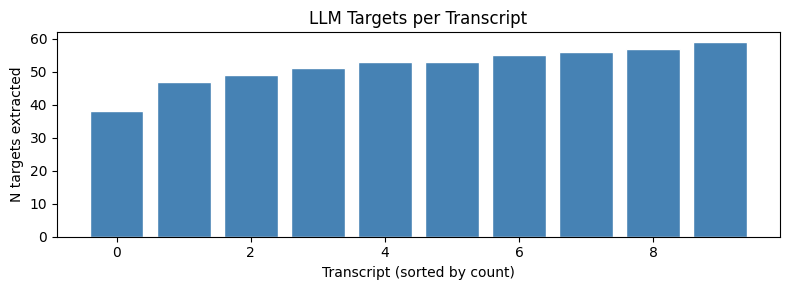

,n_targets
18711.0_2010Q4,59
18711.0_2011Q2,57
18711.0_2012Q2,56
18711.0_2011Q3,55
18711.0_2011Q4,53
18711.0_2010Q3,53
18711.0_2010Q1,51
18711.0_2010Q2,49
18711.0_2012Q1,47
18711.0_2011Q1,38


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Extraction statistics: targets per transcript, distribution
# ─────────────────────────────────────────────────────────────────────────────
target_counts = {
    tid: len(targets) for tid, targets in corpus_results.items()
}

stats_series = pd.Series(target_counts, name="n_targets")
print("Targets per transcript — summary statistics:")
print(stats_series.describe().to_string())

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(len(stats_series)), sorted(stats_series.values), color="steelblue", edgecolor="white")
ax.set_xlabel("Transcript (sorted by count)")
ax.set_ylabel("N targets extracted")
ax.set_title("LLM Targets per Transcript")
plt.tight_layout()
plt.show()

# Show per-transcript breakdown
display(stats_series.sort_values(ascending=False).to_frame())

---

## Section 6: Handling Long Transcripts

Real S&P 500 earnings call transcripts can exceed 30,000 tokens, well beyond a
single API call's practical budget.

* `LLMTargetExtractor._chunk_by_tokens()` splits at sentence boundaries using
  the model's `tiktoken` encoder so each chunk fits in
  `max_input_tokens_per_chunk` (default 12k for GPT-4o-mini).
* Across-chunk dedup is done in `LLMTargetExtractor._dedup()` using the
  canonical metric key from `prompts.canonicalize_metric()` — so
  "Gross Margin" / "gross margins" / "our gross margin" collapse to a single
  row.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Find the longest transcript in the dataset
# ─────────────────────────────────────────────────────────────────────────────
lengths = {
    t["transcript_id"]: sum(len(c["text"]) for c in t["components"])
    for t in sample_transcripts
}

longest_id = max(lengths, key=lengths.get)
longest_t  = next(t for t in sample_transcripts if t["transcript_id"] == longest_id)

print(f"Longest transcript : {longest_id}")
print(f"Total chars        : {lengths[longest_id]:,}")
print(f"Components         : {len(longest_t['components'])}")
print()
for i, comp in enumerate(longest_t["components"]):
    print(f"  Component {i}: type={comp['component_type']}, chars={len(comp['text'])}")

Longest transcript : 313055.0_2020Q1
Total chars        : 239,136
Components         : 292

  Component 0: type=2, chars=1877
  Component 1: type=2, chars=3205
  Component 2: type=2, chars=21922
  Component 3: type=2, chars=310
  Component 4: type=4, chars=39
  Component 5: type=4, chars=71
  Component 6: type=3, chars=530
  Component 7: type=4, chars=1719
  Component 8: type=3, chars=432
  Component 9: type=4, chars=846
  Component 10: type=4, chars=401
  Component 11: type=4, chars=10
  Component 12: type=3, chars=242
  Component 13: type=4, chars=792
  Component 14: type=4, chars=39
  Component 15: type=3, chars=488
  Component 16: type=4, chars=535
  Component 17: type=4, chars=21
  Component 18: type=4, chars=14
  Component 19: type=3, chars=288
  Component 20: type=4, chars=1024
  Component 21: type=4, chars=166
  Component 22: type=4, chars=160
  Component 23: type=4, chars=52
  Component 24: type=3, chars=102
  Component 25: type=4, chars=7
  Component 26: type=3, chars=63
  Co

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Demonstrate token-aware chunking on the longest component.
#
# `_chunk_by_tokens` replaced the old character-count `_chunk_text`. It uses
# the model's tiktoken encoder to split at sentence boundaries while keeping
# each chunk under `max_input_tokens_per_chunk` (default 12k for gpt-4o-mini).
#
# Lazily build a local extractor if Cell 25 hasn't been run yet, so this cell
# works in isolation.
# ─────────────────────────────────────────────────────────────────────────────
if "extractor" not in dir():
    from src.llm_extraction.llm_extractor import LLMTargetExtractor
    extractor = LLMTargetExtractor(
        backend="google",
        model="gemini-2.5-flash",
        api_key=GOOGLE_API_KEY,
        max_concurrent=20,
        temperature=0.0,
        max_input_tokens_per_chunk=12_000,
        request_timeout_s=90,
        max_retries=3,
        rpm_cap=15,
    )

longest_comp = max(longest_t["components"], key=lambda c: len(c["text"]))
long_text = longest_comp["text"]

chunks = extractor._chunk_by_tokens(long_text)

print(f"Original text  : {len(long_text):,} chars / {extractor.count_tokens(long_text):,} tokens")
print(f"Chunk budget   : {extractor.max_input_tokens_per_chunk:,} tokens")
print(f"Chunks produced: {len(chunks)}")
print()
for i, chunk in enumerate(chunks):
    n_tok = extractor.count_tokens(chunk)
    print(f"  Chunk {i+1}: {len(chunk):,} chars / {n_tok:,} tokens | "
          f"first 80 chars: {chunk[:80]!r}")


Original text  : 22,052 chars / 4,554 tokens
Chunk budget   : 12,000 tokens
Chunks produced: 1

  Chunk 1: 22,052 chars / 4,554 tokens | first 80 chars: "Well, as the video reminds us, we're driving a lot of change across this busines"


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Run extraction on the long transcript and verify chunk results are merged
# ─────────────────────────────────────────────────────────────────────────────
long_results = await extractor.extract_targets(long_text, longest_comp["component_type"])

print(f"Targets extracted from long transcript: {len(long_results)}")
print(f"(Across {len(chunks)} chunks, deduplicated by metric_name)")
print()
for t in long_results:
    print(f"  [{t.get('confidence','?'):6s}] {t.get('metric_name','?')}")

Targets extracted from long transcript: 19
(Across 1 chunks, deduplicated by metric_name)

  [high  ] private brand sales growth
  [high  ] private brand sales
  [high  ] Great Value private brand sales
  [high  ] associate retention
  [medium] InHome pilot customer retention rate
  [high  ] InHome pilot membership price
  [high  ] grocery pickup business growth
  [high  ] same-day delivery availability
  [high  ] Spark delivery volume
  [high  ] global eCommerce sales
  [medium] NPS score for felt cared for
  [high  ] Walmart U.S. store count
  [high  ] Walmart China eCommerce growth
  [high  ] hourly wage
  [high  ] quarterly bonus payout
  [high  ] 401(k) match investment
  [high  ] adoption benefit
  [high  ] health care plan cost
  [high  ] Live Better U enrollment


---

## Section 7: Error Handling

The extractor implements two layers of resilience:

1. **Malformed JSON** — parsed gracefully via regex fallback; returns `[]` rather than crashing.
2. **API failures** — exponential backoff (3 attempts) then fallback to spaCy extractor if one
   was registered; otherwise returns `[]` and logs the failure.

We test both paths here.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Test with edge-case inputs: empty string, very short text
# These should return [] without any API call.
# ─────────────────────────────────────────────────────────────────────────────
empty_result = await extractor.extract_targets("", component_type=0)
print(f"Empty string input → targets: {empty_result}  (expected: [])")

short_result = await extractor.extract_targets("Hello.", component_type=0)
print(f"Short text input → targets: {short_result}")
print("(May return [] if LLM finds no performance targets in a single greeting sentence)")

Empty string input → targets: []  (expected: [])
Short text input → targets: []
(May return [] if LLM finds no performance targets in a single greeting sentence)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Test auth failure with an obviously-invalid key.
#
# Auth failures are unrecoverable, so the extractor raises immediately — we
# expect an AuthenticationError, NOT a silent empty list. This is the contract
# the LangGraph supervisor relies on to halt the corpus run on bad credentials
# instead of writing 26,000 empty rows to disk.
# ─────────────────────────────────────────────────────────────────────────────
from openai import AuthenticationError

try:
    _bad_key_text = sample_text
    _bad_key_ctype = sample_ctype
except NameError:
    _bad_key_text = (
        "Management discussed revenue growth and margin expansion in the quarter."
    )
    _bad_key_ctype = 2

bad_extractor = LLMTargetExtractor(
    backend="openai",
    model="gpt-4o-mini",
    api_key="sk-invalid-key-for-testing-0000000000000000",
    max_concurrent=1,
    max_retries=1,
    rpm_cap=None,
    request_timeout_s=10.0,
)

print("Calling extract_targets with an invalid API key (expecting AuthenticationError)...")
raised: BaseException | None = None
try:
    await bad_extractor.extract_targets(_bad_key_text, _bad_key_ctype)
except AuthenticationError as exc:
    raised = exc
except Exception as exc:
    raised = exc

print(f"\nRaised: {type(raised).__name__}: {raised}")
print(f"Telemetry: {bad_extractor.telemetry}")
assert isinstance(raised, AuthenticationError), (
    "Expected AuthenticationError from a bad key — the bad-key test would be "
    "a no-op if the extractor swallowed it."
)
assert bad_extractor.telemetry["http_failures"] >= 1
print("OK — auth failure correctly surfaced and counted in telemetry.")

Calling extract_targets with an invalid API key (expecting AuthenticationError)...


ERROR:src.llm_extraction.llm_extractor:_call_llm | auth failure: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-inval*******************************0000. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}



Raised: AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-inval*******************************0000. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}
Telemetry: {'total_requests': 1, 'total_input_tokens': 0, 'total_output_tokens': 0, 'total_tokens_used': 0, 'http_failures': 1, 'empty_responses': 0, 'schema_invalid_drops': 0, 'retries': 0}
OK — auth failure correctly surfaced and counted in telemetry.


---

## Section 8: Cost Estimation

Before running the full corpus, let's extrapolate the per-call cost to the full S&P 200 dataset.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Cost extrapolation grounded in actual measurements from the pilot batch.
#
# The previous version hard-coded "2.5 calls/transcript" and arrived at ~$14
# for the full corpus. In reality, the un-aggregated extractor was issuing
# ~84 calls/transcript (one per Q&A turn, plus chunking), giving a true cost
# closer to $400-1300. This cell now derives the call ratio empirically from
# `corpus_results` (the small batch run in Section 5) instead of guessing.
# ─────────────────────────────────────────────────────────────────────────────
tel = extractor.telemetry
n_pilot_transcripts = len(corpus_results) if "corpus_results" in dir() else 1
calls_per_transcript = tel["total_requests"] / max(1, n_pilot_transcripts)
avg_input_tokens = tel["total_input_tokens"] / max(1, tel["total_requests"])
avg_output_tokens = tel["total_output_tokens"] / max(1, tel["total_requests"])

# Corpus scale per the proposal: S&P 200 × 2010-2023 quarterly = ~10000 transcripts
TOTAL_TRANSCRIPTS = 10395
TOTAL_CALLS = int(TOTAL_TRANSCRIPTS * calls_per_transcript)
ESTIMATED_INPUT_TOKENS = TOTAL_CALLS * avg_input_tokens
ESTIMATED_OUTPUT_TOKENS = TOTAL_CALLS * avg_output_tokens

# Gemini-2.5-Flash-Lite pricing (USD per 1M tokens, April 2025)
PRICE_INPUT_PER_1M = 0.1
PRICE_OUTPUT_PER_1M = 0.4
cost_input_total = ESTIMATED_INPUT_TOKENS / 1_000_000 * PRICE_INPUT_PER_1M
cost_output_total = ESTIMATED_OUTPUT_TOKENS / 1_000_000 * PRICE_OUTPUT_PER_1M
estimated_cost = cost_input_total + cost_output_total

print("Empirical pilot measurements:")
print(f"  Pilot transcripts          : {n_pilot_transcripts}")
print(f"  Calls per transcript       : {calls_per_transcript:.2f}")
print(f"  Avg input  tokens / call   : {avg_input_tokens:,.0f}")
print(f"  Avg output tokens / call   : {avg_output_tokens:,.0f}")
print()
print(f"Extrapolated to full S&P 200 corpus:")
print(f"  Total transcripts          : {TOTAL_TRANSCRIPTS:,}")
print(f"  Total API calls            : {TOTAL_CALLS:,}")
print(f"  Estimated input  tokens    : {ESTIMATED_INPUT_TOKENS:,.0f}")
print(f"  Estimated output tokens    : {ESTIMATED_OUTPUT_TOKENS:,.0f}")
print()
print(f"Cost breakdown (Gemini-2.5-Flash-Lite):")
print(f"  Input  (${PRICE_INPUT_PER_1M}/1M)         : ${cost_input_total:,.2f}")
print(f"  Output (${PRICE_OUTPUT_PER_1M}/1M)         : ${cost_output_total:,.2f}")
print(f"  TOTAL ESTIMATED COST       : ${estimated_cost:,.2f}")
print()
print(f"For comparison, GPT-4o (~33x price ratio) ~ ${estimated_cost * 33:,.2f}")

Empirical pilot measurements:
  Pilot transcripts          : 10
  Calls per transcript       : 3.20
  Avg input  tokens / call   : 5,492
  Avg output tokens / call   : 1,984

Extrapolated to full S&P 200 corpus:
  Total transcripts          : 10,395
  Total API calls            : 33,264
  Estimated input  tokens    : 182,687,967
  Estimated output tokens    : 65,992,658

Cost breakdown (Gemini-2.5-Flash-Lite):
  Input  ($0.1/1M)         : $18.27
  Output ($0.4/1M)         : $26.40
  TOTAL ESTIMATED COST       : $44.67

For comparison, GPT-4o (~33x price ratio) ~ $1,473.97


---

## Section 9: Full Corpus Extraction

The cell below processes the full transcript corpus.  Given the sample dataset has ~32 rows,
this will complete quickly.  For the full S&P 500 dataset (~26,000 transcripts), expect 30–60
minutes with `max_concurrent=10` on a production API key.

> **Note**: This cell makes live API calls and incurs charges.  Verify your key and budget
> before running.  The output is saved to `data/processed/llm_targets.parquet` for downstream use.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Run extraction on the full available corpus with progress tracking.
#
# Uses the resumable JSONL writer: one line per finished transcript is appended
# to data/processed/llm_targets.jsonl. Re-running this cell after Ctrl-C or a
# crash skips transcripts already on disk, so no work is wasted.
#
# Performance fix: extract_transcript now aggregates components by type before
# chunking, dropping API calls/transcript from ~84 to ~3-6 (one per type, plus
# token-budget chunking on long presentations).
# ─────────────────────────────────────────────────────────────────────────────
extractor.reset_telemetry()

JSONL_PATH = DATA_PROCESSED / "llm_targets.jsonl"

n_already_done = 0
if JSONL_PATH.exists():
    with JSONL_PATH.open() as _f:
        n_already_done = sum(1 for _ in _f)

n_total = len(sample_transcripts)
n_todo = n_total - n_already_done
print(f"Total transcripts        : {n_total}")
print(f"Already in {JSONL_PATH.name} : {n_already_done}")
print(f"To process this run      : {n_todo}")

if n_todo == 0:
    print("Nothing to do — all transcripts already extracted.")
else:
    pbar = tqdm(total=n_todo, desc="LLM extraction")

    def _on_progress(done: int, total: int) -> None:
        pbar.update(1)

    t_start = time.time()
    await extractor.extract_corpus_to_jsonl(
        sample_transcripts,
        out_path=JSONL_PATH,
        max_concurrent=10,
        progress_cb=_on_progress,
    )
    elapsed = time.time() - t_start
    pbar.close()

    tel_full = extractor.telemetry
    print(f"\nCompleted in {elapsed:.1f}s ({elapsed/60:.1f} min)")
    print(f"Total requests        : {tel_full['total_requests']:,}")
    print(f"Input  tokens used    : {tel_full['total_input_tokens']:,}")
    print(f"Output tokens used    : {tel_full['total_output_tokens']:,}")
    print(f"Total tokens used     : {tel_full['total_tokens_used']:,}")
    print(f"HTTP failures         : {tel_full['http_failures']:,}")
    print(f"Empty / parse drops   : "
          f"{tel_full['empty_responses']:,} / {tel_full['schema_invalid_drops']:,}")
    print(f"Retries               : {tel_full['retries']:,}")


Total transcripts        : 10395
Already in llm_targets.jsonl : 1152
To process this run      : 9243


LLM extraction:   0%|          | 0/9243 [00:00<?, ?it/s]


Completed in 30896.3s (514.9 min)
Total requests        : 28,006
Input  tokens used    : 150,874,432
Output tokens used    : 54,576,970
Total tokens used     : 205,451,402
HTTP failures         : 278
Empty / parse drops   : 0 / 1
Retries               : 278


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Flatten the resumable JSONL into a parquet for downstream notebooks.
#
# transcript_id is the canonical "{company_id}_{year}Q{quarter}" key written by
# build_transcript_list(). We parse it back into (company_id, fiscalyear,
# fiscalquarter) so the merge with spaCy in Section 10 is on identical keys.
# ─────────────────────────────────────────────────────────────────────────────
import re as _re
import json
import pandas as pd

_TID_RX = _re.compile(r"^(?P<company_id>[^_]+)_(?P<fiscalyear>\d{4})Q(?P<fiscalquarter>\d)$")

all_llm_rows: list[dict] = []
with JSONL_PATH.open() as _f:
    for line in _f:
        line = line.strip()
        if not line:
            continue
        rec = json.loads(line)
        tid = rec["transcript_id"]
        m = _TID_RX.match(tid)
        if m:
            company_id = m.group("company_id").split(".")[0]
            fy = int(m.group("fiscalyear"))
            fq = int(m.group("fiscalquarter"))
            quarter = f"{fy}Q{fq}"
        else:
            company_id, fy, fq, quarter = tid, None, None, ""
        for t in rec.get("targets", []):
            all_llm_rows.append({
                "transcript_id": tid,
                "company_id": company_id,
                "fiscalyear": fy,
                "fiscalquarter": fq,
                "quarter": quarter,
                **t,
            })

llm_targets_df = pd.DataFrame(all_llm_rows)
if "fiscalyear" in llm_targets_df.columns:
    llm_targets_df["fiscalyear"] = llm_targets_df["fiscalyear"].astype("Int64")
    llm_targets_df["fiscalquarter"] = llm_targets_df["fiscalquarter"].astype("Int64")

# Ensure numerical_value is numeric to avoid ArrowInvalid errors when saving to Parquet
if "numerical_value" in llm_targets_df.columns:
    llm_targets_df["numerical_value"] = pd.to_numeric(llm_targets_df["numerical_value"], errors="coerce")

out_path = DATA_PROCESSED / "llm_targets.parquet"
llm_targets_df.to_parquet(out_path, index=False)

print(f"Saved {len(llm_targets_df):,} target rows from {llm_targets_df['transcript_id'].nunique()} transcripts")
print(f"  -> {out_path}")
print(f"Columns: {list(llm_targets_df.columns)}")
llm_targets_df.head()


Saved 532,433 target rows from 10395 transcripts
  -> /content/drive/MyDrive/EarningsLens/data/processed/llm_targets.parquet
Columns: ['transcript_id', 'company_id', 'fiscalyear', 'fiscalquarter', 'quarter', 'metric_name', 'raw_text', 'numerical_value', 'trend_direction', 'unit', 'temporal_framing', 'is_financial', 'confidence', 'canonical_name', 'component_type', 'numerical_direction', 'trend_unit', 'trend_direction_vs_prev_qtr', 'unit_vs_prev_qtr', 'temporal_fra ming', 'temporal_###', 'temporal_\u2062</']


,transcript_id,company_id,fiscalyear,fiscalquarter,quarter,metric_name,raw_text,numerical_value,trend_direction,unit,...,confidence,canonical_name,component_type,numerical_direction,trend_unit,trend_direction_vs_prev_qtr,unit_vs_prev_qtr,temporal_fra ming,temporal_###,temporal_⁢</
0,18711.0_2012Q1,18711,2012,1,2012Q1,operating return on equity,generate an operating return on equity of 13% by 2014,13.0,increasing,percent,...,high,operating return equity,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,18711.0_2012Q1,18711,2012,1,2012Q1,auto insurance margins,maintaining margins in the auto insurance business at in...,NaN,stable,percent,...,high,auto insurance margin,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,18711.0_2012Q1,18711,2012,1,2012Q1,homeowners and Allstate Financial returns,improving returns in homeowners and Allstate Financial,NaN,increasing,None,...,high,homeowner allstate financial return,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,18711.0_2012Q1,18711,2012,1,2012Q1,capital management,aggressively managing our capital,NaN,increasing,None,...,medium,capital management,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,18711.0_2012Q1,18711,2012,1,2012Q1,Allstate brand Standard Auto combined ratio,combined ratio of 95.7 for the Allstate brand Standard A...,95.7,increasing,percent,...,high,allstate brand standard auto combined ratio,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---

## Section 10: Quality Assessment

Compare LLM extraction counts with spaCy extraction counts across all transcripts to identify
systematic differences and flag transcripts that warrant manual review.

In [ ]:
# Identify missing components

counts = llm_targets_df.groupby("transcript_id").size()
print(counts.describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.95, 0.99]).round(1))
print(f"\nTranscripts with <5 targets:  {(counts < 5).sum()}")
print(f"Transcripts with <10 targets: {(counts < 10).sum()}")
print(f"Transcripts with <20 targets: {(counts < 20).sum()}")

coverage = (
    llm_targets_df.groupby(["transcript_id", "component_type"]).size()
    .unstack(fill_value=0)
)
print(f"\nPer-component, transcripts with ≥1 row:\n{(coverage > 0).sum()}")
print(f"\nTranscripts missing ≥1 component: {(coverage == 0).any(axis=1).sum()}")

count    10395.0
mean        51.2
std          6.4
min          6.0
1%          29.0
5%          40.0
10%         44.0
25%         49.0
50%         52.0
75%         55.0
95%         58.0
99%         60.0
max        102.0
dtype: float64

Transcripts with <5 targets:  0
Transcripts with <10 targets: 1
Transcripts with <20 targets: 52

Per-component, transcripts with ≥1 row:
component_type
2    10287
3    10313
4    10326
dtype: int64

Transcripts missing ≥1 component: 191


In [ ]:
# Identify the 191 transcripts missing at least one component
coverage = (
    llm_targets_df.groupby(["transcript_id", "component_type"]).size()
    .unstack(fill_value=0)
)
suspect_ids = coverage[(coverage == 0).any(axis=1)].index.tolist()
print(f"suspect transcripts: {len(suspect_ids)}")

# How many targets did they get total?
suspect_counts = llm_targets_df[llm_targets_df["transcript_id"].isin(suspect_ids)] \
    .groupby("transcript_id").size()
print(f"\nTarget-count distribution of suspect transcripts:")
print(suspect_counts.describe(percentiles=[0.05, 0.5, 0.95]).round(1))

# How many are also in the bottom-of-distribution tail?
bottom_52 = llm_targets_df.groupby("transcript_id").size().nsmallest(52).index
overlap = set(suspect_ids) & set(bottom_52)
print(f"\nSuspect AND bottom-52: {len(overlap)}")

suspect transcripts: 191

Target-count distribution of suspect transcripts:
count    191.0
mean      28.9
std        8.9
min        6.0
5%        15.5
50%       32.0
95%       39.5
max       66.0
dtype: float64

Suspect AND bottom-52: 52


In [ ]:
suspect_transcripts = [t for t in sample_transcripts if t["transcript_id"] in suspect_ids]
# Save to a transient JSONL, then merge

import os
SUSPECT_JSONL = DATA_PROCESSED / "llm_targets_suspect_rerun.jsonl"
if SUSPECT_JSONL.exists():
    os.remove(SUSPECT_JSONL)

await extractor.extract_corpus_to_jsonl(
    suspect_transcripts,
    out_path=SUSPECT_JSONL,
    max_concurrent=8,           # low concurrency, no throttling risk
    progress_cb=_on_progress,
)

In [ ]:
import json
import pandas as pd
from pathlib import Path

SUSPECT_JSONL = DATA_PROCESSED / "llm_targets_suspect_rerun.jsonl"
PRIMARY_PARQUET = DATA_PROCESSED / "llm_targets.parquet"

# ---------- 1. Load rerun JSONL into a long DataFrame ----------
rerun_records = []
with SUSPECT_JSONL.open() as f:
    for line in f:
        rerun_records.append(json.loads(line))

# Flatten to per-target rows the same way NB03's main parquet build does.
rerun_rows = []
for rec in rerun_records:
    tid = rec["transcript_id"]
    for item in rec.get("targets", []):
        row = {"transcript_id": tid, **item}
        rerun_rows.append(row)

rerun_df = pd.DataFrame(rerun_rows)

if not rerun_df.empty:
    rerun_df["numerical_value"] = pd.to_numeric(
        rerun_df.get("numerical_value"), errors="coerce"
    )
    print(f"Rerun: {len(rerun_df):,} target rows from "
          f"{rerun_df['transcript_id'].nunique()} transcripts")
else:
    print("Rerun: 0 target rows found.")
    rerun_df = pd.DataFrame(columns=["transcript_id", "numerical_value"])

# ---------- 2. Compare per-transcript counts ----------
primary_df = pd.read_parquet(PRIMARY_PARQUET)

orig_counts = (
    primary_df[primary_df["transcript_id"].isin(suspect_ids)]
    .groupby("transcript_id").size().rename("orig")
)
rerun_counts = rerun_df.groupby("transcript_id").size().rename("rerun")

cmp = pd.concat([orig_counts, rerun_counts], axis=1).fillna(0).astype(int)
cmp["delta"] = cmp["rerun"] - cmp["orig"]
cmp["pct_gain"] = (cmp["delta"] / cmp["orig"].replace(0, 1)) * 100

# ---------- 3. Classify ----------
THRESHOLD_PCT = 30.0  # rerun ≥30% larger ⇒ throttling damage, replace

cmp["decision"] = "keep_original"
cmp.loc[cmp["pct_gain"] >= THRESHOLD_PCT, "decision"] = "replace_with_rerun"

n_replace = (cmp["decision"] == "replace_with_rerun").sum()
n_keep    = (cmp["decision"] == "keep_original").sum()

print(f"\nDecision summary:")
print(f"  replace_with_rerun: {n_replace}  (rerun ≥{THRESHOLD_PCT:.0f}% larger)")
print(f"  keep_original:      {n_keep}")

print("\nTop 20 by gain:")
print(cmp.sort_values("pct_gain", ascending=False).head(20))

print("\nDistribution of pct_gain across the 191:")
print(cmp["pct_gain"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(1))


Rerun: 5,526 target rows from 191 transcripts

Decision summary:
  replace_with_rerun: 0  (rerun ≥30% larger)
  keep_original:      191

Top 20 by gain:
                    orig  rerun  delta  pct_gain       decision
transcript_id                                                  
124423.0_2015Q3       17     17      0       0.0  keep_original
124423.0_2017Q2       35     35      0       0.0  keep_original
124423.0_2017Q3       28     28      0       0.0  keep_original
124423.0_2017Q4       36     36      0       0.0  keep_original
124423.0_2018Q1       35     35      0       0.0  keep_original
124423.0_2018Q2       39     39      0       0.0  keep_original
124423.0_2018Q3       30     30      0       0.0  keep_original
124423.0_2018Q4       38     38      0       0.0  keep_original
135470.0_2010Q4       66     66      0       0.0  keep_original
135506.0_2017Q4       20     20      0       0.0  keep_original
137473239.0_2018Q1    18     18      0       0.0  keep_original
139488.0_2020Q4

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Compare LLM vs spaCy extractions on the SAME (firm, year, quarter) keys.
#
# Key methodology fix vs the previous version of this cell:
#   * INNER join on (company_id, fiscalyear, fiscalquarter) — the previous
#     outer-join + fillna(0) created 1,000+ phantom rows where one of the two
#     extractors had no coverage by construction, contaminating every
#     diagnostic in the next cell.
#   * Both methods are now normalised through canonicalize_metric() so
#     "Gross Margin" and "gross margins" collapse to the same key on both
#     sides — the count comparison reflects real semantic disagreement, not
#     surface-form variation.
# ─────────────────────────────────────────────────────────────────────────────
from src.llm_extraction.prompts import canonicalize_metric

spacy_targets_df = pd.read_parquet(DATA_PROCESSED / "spacy_targets.parquet")


def _norm_company(x: object) -> str:
    s = str(x).strip()
    return s[:-2] if s.endswith(".0") else s


# spaCy side: build canonical per-firm-quarter sets (drop empty / unmatchable rows).
spacy_norm = (
    spacy_targets_df
    .assign(
        company_id=lambda d: d["companyid"].map(_norm_company),
        fiscalyear=lambda d: d["fiscalyear"].astype("Int64"),
        fiscalquarter=lambda d: d["fiscalquarter"].astype("Int64"),
        canonical_name=lambda d: (
            d.get("normalized_text", d.get("target_text", pd.Series([], dtype=str)))
             .astype(str).map(canonicalize_metric)
        ),
    )
    .loc[lambda d: d["canonical_name"].astype(bool)]
)
spacy_sets = (
    spacy_norm.groupby(["company_id", "fiscalyear", "fiscalquarter"])["canonical_name"]
              .apply(lambda s: frozenset(s))
              .reset_index(name="spacy_set")
)
spacy_sets["spacy_count"] = spacy_sets["spacy_set"].map(len)

# LLM side: parse keys from transcript_id and use the canonical_name we already
# annotate at extraction time (LLMTargetExtractor._dedup).
_TID_RX = re.compile(r"^(?P<company_id>[^_]+)_(?P<fiscalyear>\d{4})Q(?P<fiscalquarter>\d)$")
parsed = llm_targets_df["transcript_id"].str.extract(_TID_RX)

llm_norm = llm_targets_df.assign(
    company_id=parsed["company_id"].map(_norm_company),
    fiscalyear=pd.to_numeric(parsed["fiscalyear"], errors="coerce").astype("Int64"),
    fiscalquarter=pd.to_numeric(parsed["fiscalquarter"], errors="coerce").astype("Int64"),
    canonical_name=lambda d: (
        d["canonical_name"] if "canonical_name" in d.columns
        else d["metric_name"].astype(str).map(canonicalize_metric)
    ),
).loc[lambda d: d["canonical_name"].astype(bool)]

llm_sets = (
    llm_norm.dropna(subset=["company_id", "fiscalyear", "fiscalquarter"])
            .groupby(["company_id", "fiscalyear", "fiscalquarter"])["canonical_name"]
            .apply(lambda s: frozenset(s))
            .reset_index(name="llm_set")
)
llm_sets["llm_count"] = llm_sets["llm_set"].map(len)

# INNER join — only firm-quarters covered by both pipelines.
counts_merged = spacy_sets.merge(
    llm_sets, on=["company_id", "fiscalyear", "fiscalquarter"], how="inner",
)
counts_merged["spacy_count"] = counts_merged["spacy_count"].astype(int)
counts_merged["llm_count"] = counts_merged["llm_count"].astype(int)
counts_merged["difference"] = counts_merged["llm_count"] - counts_merged["spacy_count"]
counts_merged["overlap_count"] = counts_merged.apply(
    lambda r: len(r["spacy_set"] & r["llm_set"]), axis=1
)
counts_merged["llm_only_count"] = counts_merged.apply(
    lambda r: len(r["llm_set"] - r["spacy_set"]), axis=1
)
counts_merged["spacy_only_count"] = counts_merged.apply(
    lambda r: len(r["spacy_set"] - r["llm_set"]), axis=1
)
denom = counts_merged[["spacy_count", "llm_count"]].max(axis=1).replace(0, pd.NA)
counts_merged["jaccard"] = counts_merged["overlap_count"] / denom

print(f"spaCy firm-quarters with output : {len(spacy_sets):,}")
print(f"LLM   firm-quarters with output : {len(llm_sets):,}")
print(f"INNER-join firm-quarters        : {len(counts_merged):,}")
print()
print("Sample of inner-joined comparison rows:")
display(
    counts_merged[
        ["company_id", "fiscalyear", "fiscalquarter",
         "spacy_count", "llm_count", "overlap_count",
         "llm_only_count", "spacy_only_count", "jaccard"]
    ].head(15)
)

spaCy firm-quarters with output : 10,395
LLM   firm-quarters with output : 10,395
INNER-join firm-quarters        : 10,395

Sample of inner-joined comparison rows:


,company_id,fiscalyear,fiscalquarter,spacy_count,llm_count,overlap_count,llm_only_count,spacy_only_count,jaccard
0,100231,2010,1,35,57,1,56,34,0.017544
1,100231,2010,2,19,52,2,50,17,0.038462
2,100231,2010,3,30,45,2,43,28,0.044444
3,100231,2010,4,28,52,4,48,24,0.076923
4,100231,2011,1,28,47,1,46,27,0.021277
5,100231,2011,2,19,56,1,55,18,0.017857
6,100231,2011,3,32,49,1,48,31,0.020408
7,100231,2011,4,31,41,4,37,27,0.097561
8,100231,2012,1,33,54,2,52,31,0.037037
9,100231,2012,2,27,52,1,51,26,0.019231


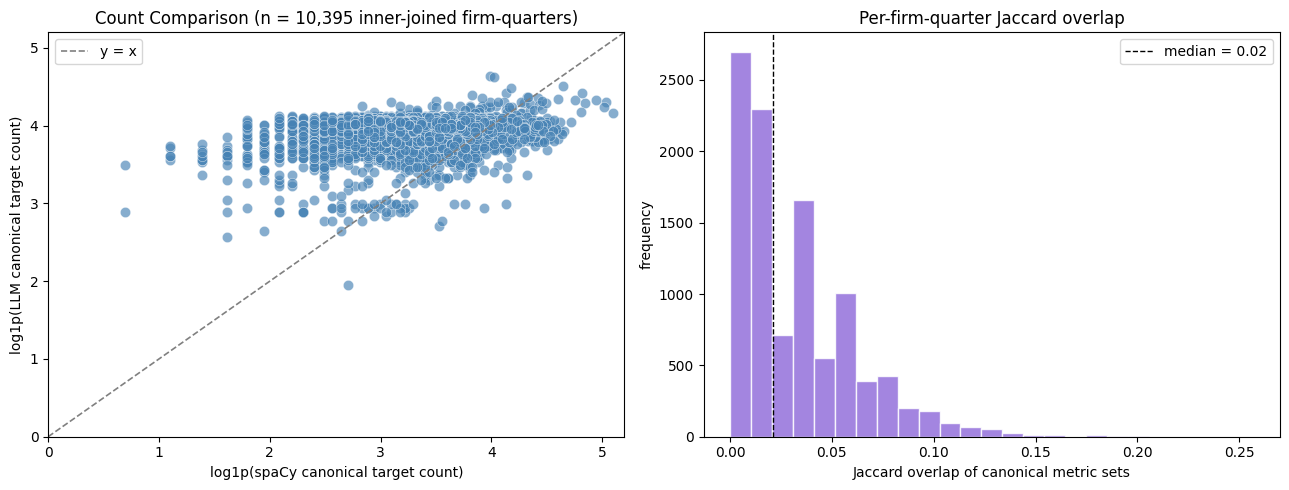

Inner-joined firm-quarters     : 10,395
Pearson  (counts)              : 0.139
Spearman (counts)              : 0.042
Median Jaccard (set overlap)   : 0.021
Mean   diff (LLM - spaCy)      : +19.41
Median diff (LLM - spaCy)      : +21.00
% LLM > spaCy / equal / less   : 90.4% / 0.9% / 8.7%


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Diagnostic comparison on the inner-joined panel.
# Left  : log1p scatter of LLM vs spaCy counts (n = inner-join rows).
# Right : Jaccard overlap of canonical metric sets per firm-quarter.
# ─────────────────────────────────────────────────────────────────────────────
plot_df = counts_merged.copy()
if plot_df.empty:
    print("No overlapping firm-quarters between spaCy and LLM panels.")
    print("Run the LLM extraction (Cell 40) on the spaCy panel first.")
else:
    x = np.log1p(plot_df["spacy_count"])
    y = np.log1p(plot_df["llm_count"])

    pearson = plot_df[["spacy_count", "llm_count"]].corr(method="pearson").iloc[0, 1]
    spearman = plot_df[["spacy_count", "llm_count"]].corr(method="spearman").iloc[0, 1]
    mean_diff = plot_df["difference"].mean()
    median_diff = plot_df["difference"].median()
    median_jaccard = plot_df["jaccard"].dropna().median()
    pct_above = (plot_df["difference"] > 0).mean() * 100
    pct_below = (plot_df["difference"] < 0).mean() * 100
    pct_equal = (plot_df["difference"] == 0).mean() * 100

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    ax1.scatter(x, y, alpha=0.65, s=55, color="steelblue",
                edgecolors="white", linewidth=0.4)
    max_log = float(max(x.max(), y.max()) + 0.1)
    ax1.plot([0, max_log], [0, max_log], "--", color="gray", linewidth=1.2,
             label="y = x")
    ax1.set_xlim(0, max_log)
    ax1.set_ylim(0, max_log)
    ax1.set_xlabel("log1p(spaCy canonical target count)")
    ax1.set_ylabel("log1p(LLM canonical target count)")
    ax1.set_title(f"Count Comparison (n = {len(plot_df):,} inner-joined firm-quarters)")
    ax1.legend(loc="upper left")

    ax2.hist(plot_df["jaccard"].dropna(), bins=25, color="mediumpurple",
             edgecolor="white", alpha=0.85)
    ax2.axvline(median_jaccard, color="black", linestyle="--", linewidth=1,
                label=f"median = {median_jaccard:.2f}")
    ax2.set_xlabel("Jaccard overlap of canonical metric sets")
    ax2.set_ylabel("frequency")
    ax2.set_title("Per-firm-quarter Jaccard overlap")
    ax2.legend()

    plt.tight_layout()
    plt.show()

    print(f"Inner-joined firm-quarters     : {len(plot_df):,}")
    print(f"Pearson  (counts)              : {pearson:.3f}")
    print(f"Spearman (counts)              : {spearman:.3f}")
    print(f"Median Jaccard (set overlap)   : {median_jaccard:.3f}")
    print(f"Mean   diff (LLM - spaCy)      : {mean_diff:+.2f}")
    print(f"Median diff (LLM - spaCy)      : {median_diff:+.2f}")
    print(f"% LLM > spaCy / equal / less   : "
          f"{pct_above:.1f}% / {pct_equal:.1f}% / {pct_below:.1f}%")

In [ ]:
print(counts_merged[["llm_count", "spacy_count", "overlap_count",
                     "llm_only_count", "spacy_only_count", "jaccard"]].describe())
print(f"\nFirm-quarters with zero LLM overlap : "
      f"{(counts_merged['overlap_count'] == 0).sum()}")
print(f"Firm-quarters with full agreement   : "
      f"{(counts_merged['jaccard'] == 1.0).sum()}")

          llm_count   spacy_count  overlap_count  llm_only_count  \
count  10395.000000  10395.000000   10395.000000    10395.000000   
mean      51.220106     31.815007       1.649062       49.571044   
std        6.351714     13.799275       1.539543        6.514414   
min        6.000000      1.000000       0.000000        6.000000   
25%       49.000000     22.000000       0.000000       47.000000   
50%       52.000000     30.000000       1.000000       51.000000   
75%       55.000000     39.000000       2.000000       54.000000   
max      102.000000    163.000000      11.000000      100.000000   

       spacy_only_count       jaccard  
count      10395.000000  10395.000000  
mean          30.165945      0.031849  
std           13.404674      0.029938  
min            1.000000      0.000000  
25%           21.000000      0.000000  
50%           28.000000      0.021277  
75%           37.000000      0.048780  
max          159.000000      0.257143  

Firm-quarters with zero LL

In [ ]:
# Coverage diagnostic — separate from the inner-joined comparison above.
# This shows where each pipeline has unique coverage so we can tell scope-mismatch
# (one pipeline didn't run on this firm-quarter) apart from real disagreement
# (both ran but extracted different metrics).
spacy_keys = set(map(tuple, spacy_sets[["company_id", "fiscalyear", "fiscalquarter"]].values))
llm_keys = set(map(tuple, llm_sets[["company_id", "fiscalyear", "fiscalquarter"]].values))

print(f"Firm-quarters with spaCy output only : {len(spacy_keys - llm_keys):,}")
print(f"Firm-quarters with LLM   output only : {len(llm_keys - spacy_keys):,}")
print(f"Firm-quarters with BOTH (inner-join) : {len(spacy_keys & llm_keys):,}")
print(f"Firm-quarters total                  : {len(spacy_keys | llm_keys):,}")

Firm-quarters with spaCy output only : 0
Firm-quarters with LLM   output only : 0
Firm-quarters with BOTH (inner-join) : 10,395
Firm-quarters total                  : 10,395


In [ ]:
# Top firm-quarters by absolute disagreement — best targets for manual review.
# We use |difference| but only on the inner-joined panel so we know both
# pipelines actually saw this transcript.
top_disagreements = counts_merged.reindex(
    counts_merged["difference"].abs().nlargest(20).index
).sort_values("difference")

display(top_disagreements[
    ["company_id", "fiscalyear", "fiscalquarter",
     "spacy_count", "llm_count", "difference",
     "overlap_count", "jaccard"]
])

,company_id,fiscalyear,fiscalquarter,spacy_count,llm_count,difference,overlap_count,jaccard
7586,317627,2011,1,163,63,-100,4,0.024540
7587,317627,2011,2,150,68,-82,6,0.040000
7582,317627,2010,1,152,73,-79,4,0.026316
7588,317627,2011,3,139,75,-64,4,0.028777
7584,317627,2010,3,121,64,-57,6,0.049587
1930,177031,2016,3,111,56,-55,1,0.009009
1932,177031,2017,1,99,45,-54,4,0.040404
1933,177031,2017,2,104,50,-54,5,0.048077
7583,317627,2010,2,126,72,-54,3,0.023810
1935,177031,2017,4,102,48,-54,9,0.088235


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Drill-down: for the top-disagreement firm-quarter, show which canonical
# metrics each pipeline emitted (LLM-only, spaCy-only, shared). This is
# the diff a human annotator would actually score.
# ─────────────────────────────────────────────────────────────────────────────
if not counts_merged.empty:
    counts_merged["abs_diff"] = counts_merged["difference"].abs()
    pick = counts_merged.sort_values("abs_diff", ascending=False).iloc[0]
    sp_set = pick["spacy_set"]
    llm_set = pick["llm_set"]
    print(f"Firm-quarter under review: company_id={pick['company_id']} "
          f"{int(pick['fiscalyear'])}Q{int(pick['fiscalquarter'])}")
    print(f"  spaCy targets         : {pick['spacy_count']}")
    print(f"  LLM   targets         : {pick['llm_count']}")
    print(f"  Overlap               : {pick['overlap_count']}")
    print(f"  Jaccard               : {pick['jaccard']:.3f}")
    print(f"\nSHARED ({len(sp_set & llm_set)}):")
    for m in sorted(sp_set & llm_set)[:25]:
        print(f"   = {m}")
    print(f"\nLLM-only ({len(llm_set - sp_set)}):")
    for m in sorted(llm_set - sp_set)[:25]:
        print(f"   + {m}")
    print(f"\nspaCy-only ({len(sp_set - llm_set)}):")
    for m in sorted(sp_set - llm_set)[:25]:
        print(f"   - {m}")
    print()
    print("Interpretation: 'LLM-only' rows are typically the qualitative or")
    print("trend-based targets spaCy NER misses. 'spaCy-only' rows are usually")
    print("noise (numeric tokens with no real KPI structure) — manual review")
    print("on a few of these is the basis of the F1 evaluation in §4 of the proposal.")
else:
    print("No inner-joined firm-quarters to review yet.")

Firm-quarter under review: company_id=317627 2011Q1
  spaCy targets         : 163
  LLM   targets         : 63
  Overlap               : 4
  Jaccard               : 0.025

SHARED (4):
   = consolidated revenue
   = share
   = u s des revenue
   = worldwide des revenue

LLM-only (59):
   + acquisition revenue impact
   + comparable run rate eps
   + consolidated revenue decline
   + cost new product introduction taxu element icd pacemaker
   + des market growth
   + des penetration rate
   + earnings split throughout year
   + earnings year over year change vs
   + emea des market share
   + emea element platform revenue
   + emea revenue
   + emi program value
   + eps guidance
   + eps guidance near term
   + eps tax benefit
   + european des market share
   + foreign currency impact revenue
   + gross margin
   + gross margin change year over year
   + gross margin year over year
   + guidance cost savings
   + incremental price pressure specific drug eluting stent
   + incremental p